# **Customer Engagement & Product Utilization Analytics for Retention Strategy**

## **Problem Statement**

Despite having data on customer engagement and product usage, banks often lack:

• Quantitative insight into which behaviors drive retention

• Clarity on whether product depth reduces churn

• Evidence on whether high balances alone ensure loyalty

## **Project Objectives**

• Evaluate the relationship between engagement and churn

• Measure retention impact of product count and product mix

• Identify disengaged yet high-value customers

## **Secondary Objectives**

• Support engagement-driven retention strategies

• Improve product bundling decisions

• Reduce silent churn among premium customers

### **Data Ingestion and Validation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import textwrap

In [2]:
# Load Dataset

df = pd.read_csv("..\Data\European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.shape

(10000, 14)

In [7]:
# Validate engagement and product fields

print("Missing values for each column")
print(df.isnull().sum())                    # checking for missing values

Missing values for each column
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [8]:
duplicate_count = df.duplicated().sum()        # checking for duplicate values count 
print(f"Duplicated values for each column: {duplicate_count}") 

Duplicated values for each column: 0


In [9]:
print(df['NumOfProducts'].value_counts())     # value ranges

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [10]:
# Ensure binary varibale consistency

print(df['IsActiveMember'].unique())          # ensuring consistency
print(df['HasCrCard'].unique())
print(df['Exited'].unique())

[1 0]
[1 0]
[1 0]


In [11]:
# Confirm churn labelling accuracy

print(df['Exited'].value_counts())           # value counts in the column Exited

Exited
0    7963
1    2037
Name: count, dtype: int64


## **Engagement Classification**

In [12]:
# Create engagement profiles :

def classify_engagement(row):
    if row['IsActiveMember'] == 1 and row['NumOfProducts'] > 1:
        return "Active Engeged Customers"               # Active Engaged Customers
    elif row['IsActiveMember'] == 0 and row['NumOfProducts'] == 0:
        return"Inactive disengaged Customers"           # Inactive Disengaged Customers
    elif row['IsActiveMember'] == 1 and row['NumOfProducts'] <= 1:
        return "Active, low-product Customers"          # Active but low-product customers
    elif row['IsActiveMember'] == 0 and row['Balance'] > 50000:
        return "Inactive, high-balance Customers"       # Inactive high balance customers
    else:
        return "Other"

df['EngagementProfile'] = df.apply(classify_engagement, axis = 1)
        

## **Product Utilization Analysis**

Churn Rate by product count:  NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64
Single-product churn Rate:  0.27714398111723054
Multi-product churn Rate:  0.1277461350691619


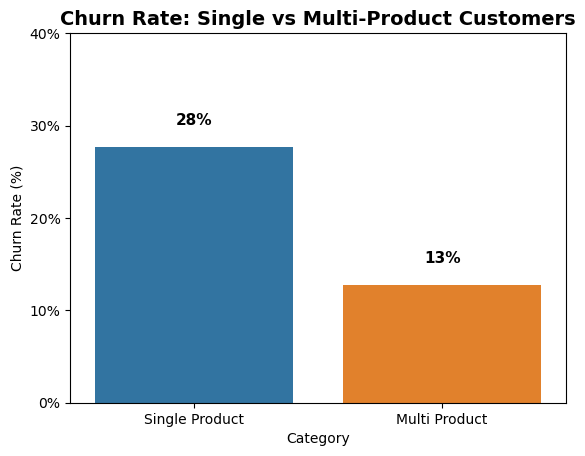

In [13]:
# Churn rate by number of products
product_churn = df.groupby('NumOfProducts')['Exited'].mean()
print("Churn Rate by product count: ", product_churn)

# Single-product vs multi-product retention
single_product_churn = df[df['NumOfProducts'] == 1]['Exited'].mean()
multi_product_churn = df[df['NumOfProducts'] > 1]['Exited'].mean()

print("Single-product churn Rate: ", single_product_churn)
print("Multi-product churn Rate: ", multi_product_churn)

# Prepare DataFrame
plot_df = pd.DataFrame({
    "Category": ["Single Product", "Multi Product"],
    "ChurnRate": [single_product_churn, multi_product_churn]
})

# Bar plot (no redundant hue)
ax = sns.barplot(data=plot_df, x="Category", y="ChurnRate", hue = "Category",
                 palette={"Single Product":"#1f77b4", "Multi Product":"#ff7f0e"}, legend=False)

plt.title("Churn Rate: Single vs Multi-Product Customers", fontsize=14, weight='bold')
plt.ylabel("Churn Rate (%)")

# Add labels above bars (whole numbers)
for i, row in plot_df.iterrows():
    ax.text(
        i, row["ChurnRate"] + 0.02,          # slightly above bar
        f"{row['ChurnRate']*100:.0f}%",      # convert to percentage, no decimals
        ha="center", va="bottom",
        color="black", fontsize=11, fontweight="bold"
    )

# Expand y-axis range for clarity
max_val = plot_df["ChurnRate"].max()
buffer = 0.05
ax.set_ylim(0, max_val + buffer)

# ✅ Force integer percentage ticks on y-axis
ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])              # convert back to fraction for plotting
ax.set_yticklabels([f"{t}%" for t in ticks])       # display as whole number percentages

plt.savefig("../Images/single_vs_multi_product.png", dpi=300, bbox_inches="tight") 
plt.show()

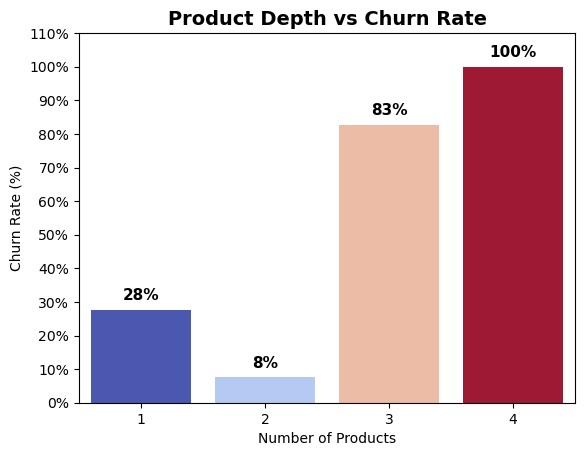

In [14]:
# Product depth vs churn relationship
product_depth_churn = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

# Create plotting DataFrame
plot_df = pd.DataFrame({
    "NumOfProducts": product_depth_churn['NumOfProducts'],
    "ChurnRate": product_depth_churn['Exited']
})

# Barplot (no redundant hue)
ax = sns.barplot(data=plot_df, x="NumOfProducts", y="ChurnRate", hue="NumOfProducts",
                 palette="coolwarm", legend=False)

plt.title("Product Depth vs Churn Rate", fontsize=14, weight='bold')
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

# Add labels above bars (whole numbers)
for i, row in plot_df.iterrows():
    ax.text(
        i, row["ChurnRate"] + 0.02,          # slightly above bar
        f"{row['ChurnRate']*100:.0f}%",      # convert to percentage, no decimals
        ha="center", va="bottom",
        color="black", fontsize=11, fontweight="bold"
    )

# Expand y-axis range for clarity
max_val = plot_df["ChurnRate"].max()
buffer = 0.05
ax.set_ylim(0, max_val + buffer)

# ✅ Force integer percentage ticks on y-axis
ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])              # convert back to fraction for plotting
ax.set_yticklabels([f"{t}%" for t in ticks])       # display as whole number percentages

plt.savefig("../Images/product_depth_vs_churn.png", dpi=300, bbox_inches="tight") 
plt.show()

### **Financial Commitment Vs Engagement Analysis**

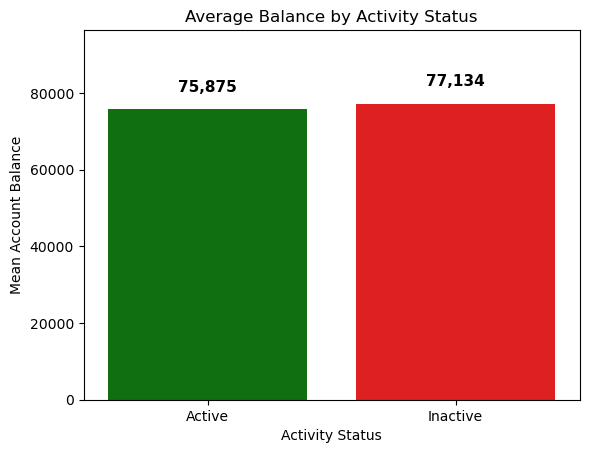

In [15]:
# Balance vs Activity cross-analysis

df['ActivityLabel'] = df['IsActiveMember'].map({0:"Inactive", 1:"Active"})

# Calculate mean balances
mean_balances = df.groupby("ActivityLabel")["Balance"].mean().reset_index()

# Bar plot with hue (fixes deprecation warning)
ax = sns.barplot( data=mean_balances, x="ActivityLabel", y="Balance",
    hue="ActivityLabel", palette={"Inactive":"red","Active":"green"}, legend=False)

plt.title("Average Balance by Activity Status")
plt.xlabel("Activity Status")
plt.ylabel("Mean Account Balance")

# Add labels above bars
for i, row in mean_balances.iterrows():
    ax.text(
        i, row["Balance"] * 1.05,       # place label slightly above bar
        f"{row['Balance']:,.0f}",       # formatted value
        ha="center", va="bottom",
        color="black", fontsize=11, fontweight="bold"
    )

# Expand y-axis range for clarity
ax.set_ylim(0, mean_balances["Balance"].max() * 1.25)
plt.savefig("../Images/avg_bal_by_activity.png", dpi=300, bbox_inches="tight") 
plt.show()

Number of mismatched customers: 1782


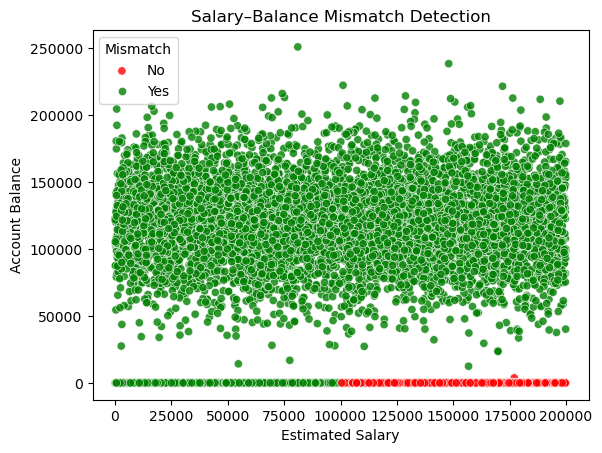

In [16]:
# Salary-balance mismatch detection

df['SalaryBalanceMismatch'] = np.where(
    (df['EstimatedSalary'] > 100000) & (df['Balance'] < 10000), 1, 0)

# Count mismatches
print("Number of mismatched customers:", df['SalaryBalanceMismatch'].sum())

# Visualization: scatter plot of Salary vs Balance
sns.scatterplot( data=df, x="EstimatedSalary", y="Balance", hue="SalaryBalanceMismatch",
                 palette={0: "green", 1: "red"}, alpha=0.8)

plt.title("Salary–Balance Mismatch Detection")
plt.xlabel("Estimated Salary")
plt.ylabel("Account Balance")
plt.legend(title="Mismatch", labels=["No", "Yes"])
plt.savefig("../Images/salary_bal_mismatch.png", dpi=300, bbox_inches="tight") 
plt.show()

At-risk premium customers: 2356


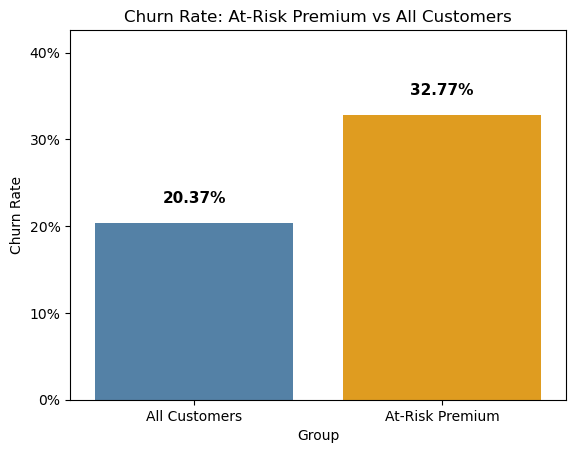

In [17]:
# Identification of "at-risk Premium Customers"

at_risk = df[(df['Balance'] > 100000) & (df['IsActiveMember'] == 0)]
print("At-risk premium customers:", at_risk.shape[0])

# Prepare churn rate DataFrame
churn_df = pd.DataFrame({
    "Group": ["All Customers", "At-Risk Premium"],
    "ChurnRate": [df['Exited'].mean(), at_risk['Exited'].mean()]
})

# Bar Chart with hue
ax = sns.barplot( data=churn_df, x="Group", y="ChurnRate", hue="Group",
    palette={"All Customers":"steelblue", "At-Risk Premium":"orange"}, legend=False)

plt.title("Churn Rate: At-Risk Premium vs All Customers")
plt.ylabel("Churn Rate")

# Add labels above bars
for i, row in churn_df.iterrows():
    ax.text(
        i, row["ChurnRate"] + 0.02,          # place label slightly above bar
        f"{row['ChurnRate']*100:.2f}%",           # formatted churn rate
        ha="center", va="bottom",
        color="black", fontsize=11, fontweight="bold"
    )

# Expand y-axis range for clarity
max_val = churn_df["ChurnRate"].max()
buffer = 0.05
ax.set_ylim(0, max_val + buffer)

# ✅ Force integer percentage ticks on y-axis
ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])              # convert back to fraction for plotting
ax.set_yticklabels([f"{t}%" for t in ticks])       # display as whole number percentages

# Expand y-axis range for clarity
ax.set_ylim(0, churn_df["ChurnRate"].max() * 1.3)
plt.savefig("../Images/at_risk_prem_vs_all.png", dpi=300, bbox_inches="tight") 
plt.show()

## **Retention Strength Assessment**

In [18]:
# Define sticky customers: active + multiple products + low churn
sticky_customers = df[(df['IsActiveMember'] == 1) & (df['NumOfProducts'] > 1) & (df['Exited'] == 0)]
print("Sticky customers:", sticky_customers.shape[0])

Sticky customers: 2338


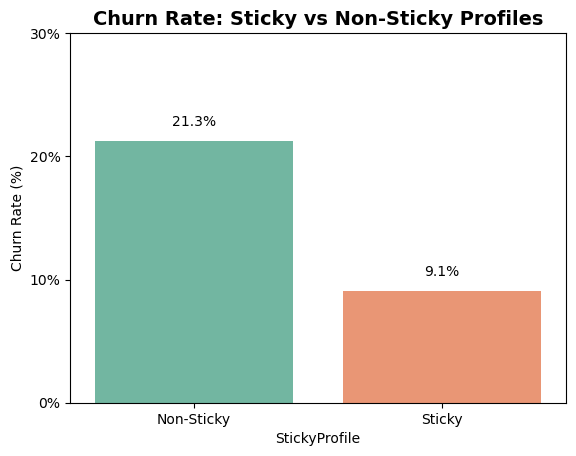

In [19]:
# 5. Retention Strength Assessment

# Helper function to add percentage labels above bars
def add_labels(ax):
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # <-- prevents 0.0% labels at baseline
            ax.annotate(f"{height:.1%}", 
                        (p.get_x() + p.get_width() / 2., height + 0.01), 
                        ha='center', va='bottom', fontsize=10, color='black')

# 1. Define "sticky customer" profiles
median_tenure = df['Tenure'].median()
def sticky_customer(row):
    if (row['IsActiveMember'] == 1 and 
        row['NumOfProducts'] > 1 and 
        row['CreditScore'] >= 650 and 
        row['Tenure'] >= median_tenure):
        return "Sticky"
    else:
        return "Non-Sticky"

df['StickyProfile'] = df.apply(sticky_customer, axis=1)

# Calculate churn rate for sticky vs non-sticky
sticky_churn = df.groupby('StickyProfile')['Exited'].mean().reset_index()

# Plot bar chart
ax = sns.barplot(x="StickyProfile", y="Exited", data=sticky_churn, hue=sticky_churn.index, palette="Set2")
plt.title("Churn Rate: Sticky vs Non-Sticky Profiles", fontsize=14, weight='bold')
plt.ylabel("Churn Rate (%)")

# Add labels above bars
add_labels(ax)

# Expand y-axis range to fit labels
max_val = sticky_churn["Exited"].max()
buffer = 0.05
ax.set_ylim(0, max_val + buffer)

# Force integer percentage ticks
ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])
ax.set_yticklabels([f"{t}%" for t in ticks])
ax.legend_.remove()

plt.savefig("../Images/Sticky vs Non-sticky.png", dpi=300, bbox_inches="tight")
plt.show()

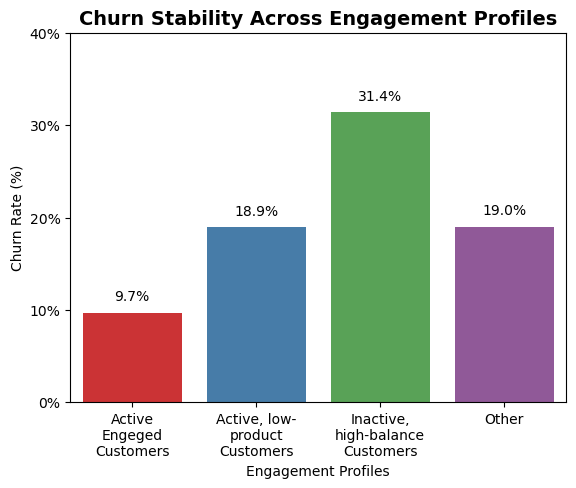

In [27]:
# Helper function to wrap labels
def wrap_labels(labels, width=12):
    return [textwrap.fill(label, width) for label in labels]

# 2. Measure churn stability across engagement tiers
engagement_churn = df.groupby('EngagementProfile')['Exited'].mean()

# Wrap the engagement profile labels
wrapped_labels = wrap_labels(engagement_churn.index, width=12)

ax = sns.barplot(x=wrapped_labels, y=engagement_churn.values, hue=wrapped_labels,
                 palette="Set1", legend=False)

plt.title("Churn Stability Across Engagement Profiles", fontsize=14, weight='bold')
plt.xlabel("Engagement Profiles")
plt.ylabel("Churn Rate (%)")

# Keep your existing add_labels function call
add_labels(ax)

# ✅ Expand y-axis and force integer percentage ticks
max_val = engagement_churn.values.max()
buffer = 0.05
ax.set_ylim(0, max_val + buffer)

ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])              # convert back to fraction for plotting
ax.set_yticklabels([f"{t}%" for t in ticks])       # display as whole number percentages

plt.savefig("../Images/engagement_profile.png", dpi=300, bbox_inches="tight") 
plt.show()

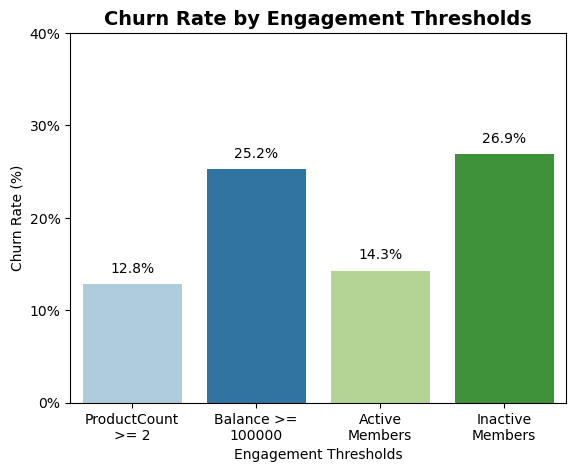

In [28]:
# 3. Identify engagement thresholds linked to retention
thresholds = {
    "ProductCount >= 2": df[df['NumOfProducts'] >= 2]['Exited'].mean(),
    "Balance >= 100000": df[df['Balance'] >= 100000]['Exited'].mean(),
    "Active Members": df[df['IsActiveMember'] == 1]['Exited'].mean(),
    "Inactive Members": df[df['IsActiveMember'] == 0]['Exited'].mean()
}

threshold_keys = list(thresholds.keys())
threshold_values = list(thresholds.values())

# Wrap the threshold labels
wrapped_labels = wrap_labels(threshold_keys, width=12)

ax = sns.barplot(x=wrapped_labels, y=threshold_values, hue=wrapped_labels,
                 palette="Paired", legend=False)

plt.title("Churn Rate by Engagement Thresholds", fontsize=14, weight='bold')
plt.xlabel("Engagement Thresholds")
plt.ylabel("Churn Rate (%)")

# Keep your existing add_labels function call
add_labels(ax)

# ✅ Expand y-axis and force integer percentage ticks
max_val = max(threshold_values)
buffer = 0.05
ax.set_ylim(0, max_val + buffer)

ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])              # convert back to fraction for plotting
ax.set_yticklabels([f"{t}%" for t in ticks])       # display as whole number percentages

plt.savefig("../Images/churn_eng_thresholds.png", dpi=300, bbox_inches="tight") 
plt.show()

# **Key Performance Indicators [KPIs]**

C:\Users\acer\AppData\Local\Temp\ipykernel_12560\1381676582.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=engagement_churn, x="Status", y="Exited", palette="Set2")


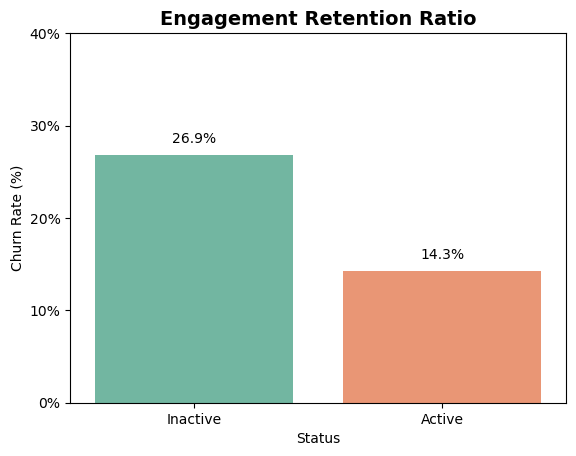

In [22]:
# Engagement Retention Ratio

# Calculate churn rate by activity status
engagement_churn = df.groupby('IsActiveMember')['Exited'].mean().reset_index()
engagement_churn['Status'] = engagement_churn['IsActiveMember'].map({1: "Active", 0: "Inactive"})

ax = sns.barplot(data=engagement_churn, x="Status", y="Exited", palette="Set2")
plt.title("Engagement Retention Ratio", fontsize=14, weight='bold')
plt.ylabel("Churn Rate (%)")

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f"{height:.1%}",
            ha="center", va="bottom", fontsize=10)

max_val = engagement_churn["Exited"].max()
buffer = 0.05
ax.set_ylim(0, max_val + buffer)

ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])
ax.set_yticklabels([f"{t}%" for t in ticks])

plt.savefig("../Images/eng_retention_ratio.png", dpi=300, bbox_inches="tight") 
plt.show()


C:\Users\acer\AppData\Local\Temp\ipykernel_12560\3982407406.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=product_churn, x="NumOfProducts", y="Exited", palette="Blues")


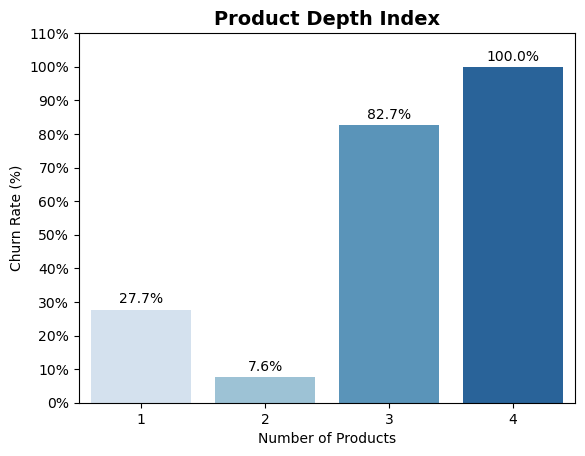

In [23]:
# Product Depth Index

# Calculate churn rate by number of products
product_churn = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

# Plot bar chart
ax = sns.barplot(data=product_churn, x="NumOfProducts", y="Exited", palette="Blues")
plt.title("Product Depth Index", fontsize=14, weight='bold')
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

# Add labels above each bar using patches
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f"{height:.1%}",
            ha="center", va="bottom", fontsize=10)

# Expand y-axis range to fit labels
max_val = product_churn["Exited"].max()
buffer = 0.05  # ensures labels fit comfortably
ax.set_ylim(0, max_val + buffer)

# Force integer percentage ticks
ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])
ax.set_yticklabels([f"{t}%" for t in ticks])

plt.savefig("../Images/product_depth_index.png", dpi=300, bbox_inches="tight") 
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_12560\3143340608.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=balance_churn, x="Segment", y="Exited", palette="Oranges")


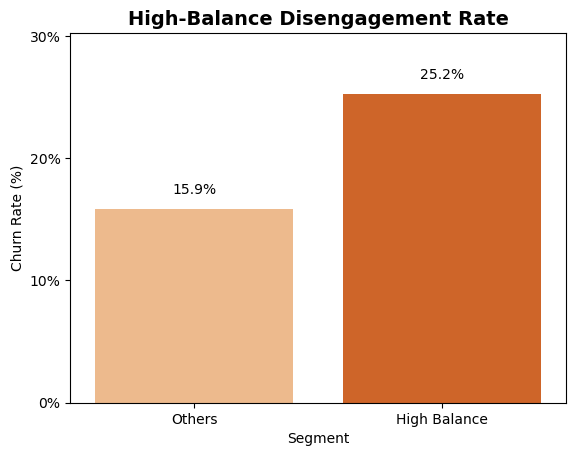

In [24]:
# High-Balance Disengagement Rate

# Define high-balance customers (threshold: 100,000)
df['HighBalance'] = (df['Balance'] >= 100000).astype(int)

# Calculate churn rate by balance segment
balance_churn = df.groupby('HighBalance')['Exited'].mean().reset_index()
balance_churn['Segment'] = balance_churn['HighBalance'].map({1: "High Balance", 0: "Others"})

# Plot bar chart
ax = sns.barplot(data=balance_churn, x="Segment", y="Exited", palette="Oranges")
plt.title("High-Balance Disengagement Rate", fontsize=14, weight='bold')
plt.ylabel("Churn Rate (%)")

# Add labels above each bar using patches
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f"{height:.1%}",
            ha="center", va="bottom", fontsize=10)

# Expand y-axis range to fit labels
max_val = balance_churn["Exited"].max()
buffer = 0.05  # ensures labels fit comfortably
ax.set_ylim(0, max_val + buffer)

# Force integer percentage ticks
ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])
ax.set_yticklabels([f"{t}%" for t in ticks])

plt.savefig("../Images/high_bal_diseng.png", dpi=300, bbox_inches="tight") 
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_12560\3434057605.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=card_churn, x="Ownership", y="Exited", palette="Greens")


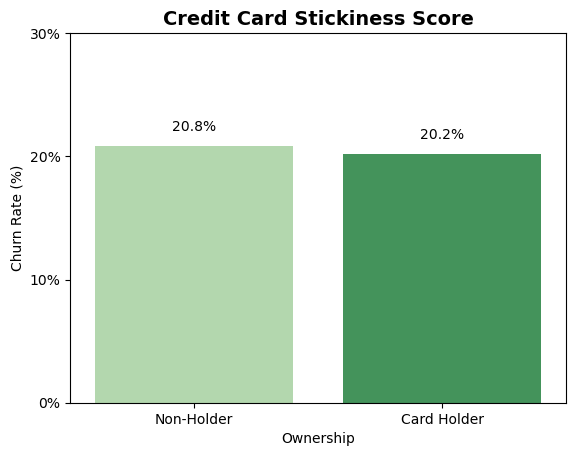

In [25]:
# Credit Card Stickiness Score

# Calculate churn rate by credit card ownership
card_churn = df.groupby('HasCrCard')['Exited'].mean().reset_index()
card_churn['Ownership'] = card_churn['HasCrCard'].map({1: "Card Holder", 0: "Non-Holder"})

# Plot bar chart
ax = sns.barplot(data=card_churn, x="Ownership", y="Exited", palette="Greens")
plt.title("Credit Card Stickiness Score", fontsize=14, weight='bold')
plt.ylabel("Churn Rate (%)")

# Add labels above each bar using patches
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f"{height:.1%}",
            ha="center", va="bottom", fontsize=10)

# Expand y-axis range to fit labels
max_val = card_churn["Exited"].max()
buffer = 0.05  # ensures labels fit comfortably
ax.set_ylim(0, max_val + buffer)

# Force integer percentage ticks
ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])
ax.set_yticklabels([f"{t}%" for t in ticks])

plt.savefig("../Images/cc_stickiness_score.png", dpi=300, bbox_inches="tight") 
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_12560\2022079326.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=rel_churn, x="RelationshipStrength", y="Exited", palette="Purples", legend = False)


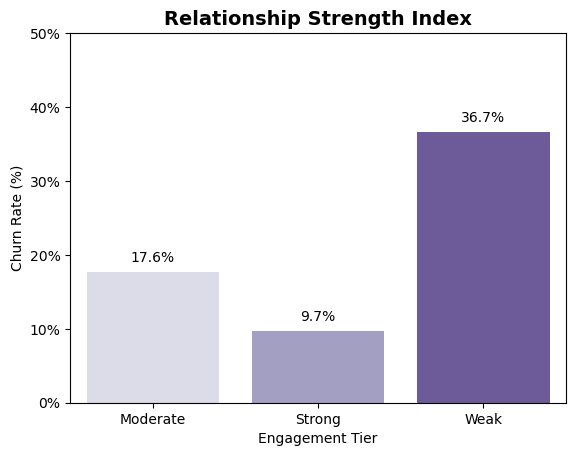

In [29]:
# Relationship Strength Index

# Define relationship strength tiers based on engagement + product depth
def relationship_strength(row):
    if row['IsActiveMember'] == 1 and row['NumOfProducts'] > 1:
        return "Strong"
    elif row['IsActiveMember'] == 1 or row['NumOfProducts'] > 1:
        return "Moderate"
    else:
        return "Weak"

# Create the RelationshipStrength column
df['RelationshipStrength'] = df.apply(relationship_strength, axis=1)

# Calculate churn rate by relationship strength
rel_churn = df.groupby('RelationshipStrength')['Exited'].mean().reset_index()

# Plot bar chart
ax = sns.barplot(data=rel_churn, x="RelationshipStrength", y="Exited", palette="Purples")
plt.title("Relationship Strength Index", fontsize=14, weight='bold')
plt.xlabel("Engagement Tier")
plt.ylabel("Churn Rate (%)")

# Add labels above each bar using patches
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height + 0.01, f"{height:.1%}",
            ha="center", va="bottom", fontsize=10)

# Expand y-axis range to fit labels
max_val = rel_churn["Exited"].max()
buffer = 0.05  # ensures labels fit comfortably
ax.set_ylim(0, max_val + buffer)

# Force integer percentage ticks
ticks = range(0, int((max_val + buffer) * 100) + 10, 10)
ax.set_yticks([t/100 for t in ticks])
ax.set_yticklabels([f"{t}%" for t in ticks])

plt.savefig("../Images/relationship_strength.png", dpi=300, bbox_inches="tight") 
plt.show()